# 01 — Look at the Data (SMB Underwriting Challenge)
Interactive EDA. Loaders come from `src/`, but everything below shows the **actual data** —
`.head()`, `.describe()`, distributions, crosstabs — so you can scroll, tweak, and poke.
Written conclusions live in `reports/eda_findings.md`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src import data
from src.config import set_seeds, PRODUCT
set_seeds()

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

tr = data.load_train(); va = data.load_validation(); te = data.load_test()
print("train", tr.shape, "| validation", va.shape, "| test", te.shape)

train (85340, 44) | validation (4489, 44) | test (8817, 44)


## 1. First look — heads and a single full row

In [2]:
tr.head(8)

,business_id,applicant_id,sector,geography_region,vintage_years,employee_count_bucket,stated_annual_revenue,stated_time_in_business,requested_amount,intended_use_of_funds,has_linked_bank_feed,observed_monthly_revenue_avg_3mo,observed_revenue_trend_3mo,observed_revenue_volatility,observed_cash_balance_p10,observed_overdraft_count_3mo,payroll_regularity_score,aggregate_credit_utilization,recent_inquiries_count_6mo,existing_debt_obligations,owner_personal_credit_band,days_since_last_external_decline,account_age_days,platform_active_months,bookkeeping_recency_days,invoice_payment_delinquency_rate,prior_loans_count,prior_loans_default_count,prior_loans_amount_total,application_timestamp,application_channel,multi_lender_inquiry_count_30d,days_since_last_inquiry_elsewhere,repeat_application_count,requested_amount_to_observed_revenue,prior_underwriter_score,prior_decision,prior_approved_amount,default_flag,days_to_default,days_to_full_repayment,repayment_status,final_recovered_amount,observation_status
0,d810eb27-c2a7-2cd5-97bc-e58632acfb02,e5a5dd55-a488-58b9-52f6-ff29313fa0d6,1,3,1.340,3,"2,658,743.911",2.350,"23,130.878",1,True,"180,062.787",0.962,0.968,"-2,267.751",0.000,0.436,0.458,0,"6,264.064",1,NaN,897,8,24.245,0.257,0,0,0.000,2024-02-26,2,0,NaN,0,0.011,0.004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,304256ad-cb60-f654-660e-2ec6cc5f66a7,cf18287f-26bb-ccf8-37d7-bc17995e5501,3,3,1.071,0,"959,666.129",1.074,"17,189.045",0,True,"80,968.368",-0.397,0.546,"-1,706.515",0.000,0.223,0.606,0,"12,600.750",0,19.411,200,6,23.378,0.241,1,1,"5,136.413",2024-10-01,0,0,7.133,0,0.018,0.903,1,"17,189.045",0.000,NaN,60.000,paid_in_full,NaN,matured
2,151b1ef3-bf46-3d0b-5b7f-37b1a5cb7c0b,9a9fe9df-da97-5fc8-a401-892030d8ebed,0,0,5.208,0,"1,671,621.472",5.548,"30,184.565",1,True,"117,083.483",-0.794,1.080,"-2,171.399",1.000,0.303,0.724,1,"7,369.819",2,27.966,1050,2,18.852,0.346,0,0,0.000,2025-06-23,0,2,14.522,0,0.021,0.280,1,"23,728.619",0.000,NaN,60.000,paid_in_full,NaN,matured
3,c4846a26-665e-7af5-1766-4a2d454d7e1c,561cc418-9a6f-e337-42ed-d4dd8364fb04,0,3,0.943,3,"1,793,170.610",1.193,"29,293.151",2,False,NaN,NaN,NaN,NaN,NaN,NaN,0.700,0,"12,456.059",2,NaN,278,16,15.391,0.214,1,0,"7,930.880",2024-07-16,0,3,21.851,0,0.016,0.086,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,b235718d-aec7-6cec-de3e-6119b60aff25,d09bfa55-a871-a120-49cb-c919001fdf3c,1,3,8.852,0,"1,364,785.837",9.080,"22,280.441",0,False,NaN,NaN,NaN,NaN,NaN,NaN,0.238,0,"6,497.925",4,NaN,490,1,11.012,0.144,0,0,0.000,2024-10-10,1,0,NaN,0,0.016,0.414,1,"22,280.441",1.000,43.000,NaN,defaulted,"1,812.743",matured
5,6528e09a-1183-7ea5-f830-0d81709a307e,09ebeea6-02fc-62c9-f915-3036e243b254,0,3,3.131,0,"1,041,255.070",3.254,"14,065.267",1,False,NaN,NaN,NaN,NaN,NaN,NaN,0.197,0,"9,632.669",3,NaN,962,2,18.437,0.043,0,0,0.000,2024-01-06,0,0,NaN,0,0.014,0.962,1,"14,065.267",0.000,NaN,60.000,paid_in_full,NaN,matured
6,b0644cf1-3d1c-cbfd-dfd1-d9dcd6bd6b50,d8d2478c-7a9b-fd35-dfbd-947338c215a1,1,0,6.223,2,"3,272,922.733",6.656,"28,885.897",0,False,NaN,NaN,NaN,NaN,NaN,NaN,0.604,0,"12,331.896",3,48.125,1420,14,13.433,0.163,0,0,0.000,2024-01-24,1,1,13.506,0,0.009,0.846,1,"28,885.897",0.000,NaN,60.000,paid_in_full,NaN,matured
7,b0644cf1-3d1c-cbfd-dfd1-d9dcd6bd6b50,5a4332a1-db4f-021c-0bbc-caeae28ac558,1,0,6.223,2,"3,109,139.421",7.396,"27,277.562",0,True,"251,849.676",0.395,1.394,"1,152.861",0.000,0.783,0.419,0,"9,822.546",3,43.603,794,15,18.155,0.141,0,0,0.000,2024-03-10,0,0,2.171,1,0.009,0.504,1,"27,277.562",0.000,NaN,60.000,paid_in_full,NaN,matured


In [3]:
# one application, transposed, so you can read all 44 fields at once
tr.iloc[0].to_frame("example_train_row")

,example_train_row
business_id,d810eb27-c2a7-2cd5-97bc-e58632acfb02
applicant_id,e5a5dd55-a488-58b9-52f6-ff29313fa0d6
sector,1
geography_region,3
vintage_years,1.340
employee_count_bucket,3
stated_annual_revenue,"2,658,743.911"
stated_time_in_business,2.350
requested_amount,"23,130.878"
intended_use_of_funds,1


In [4]:
# test row: outcome columns are all blank here
te.head(5)

,business_id,applicant_id,sector,geography_region,vintage_years,employee_count_bucket,stated_annual_revenue,stated_time_in_business,requested_amount,intended_use_of_funds,has_linked_bank_feed,observed_monthly_revenue_avg_3mo,observed_revenue_trend_3mo,observed_revenue_volatility,observed_cash_balance_p10,observed_overdraft_count_3mo,payroll_regularity_score,aggregate_credit_utilization,recent_inquiries_count_6mo,existing_debt_obligations,owner_personal_credit_band,days_since_last_external_decline,account_age_days,platform_active_months,bookkeeping_recency_days,invoice_payment_delinquency_rate,prior_loans_count,prior_loans_default_count,prior_loans_amount_total,application_timestamp,application_channel,multi_lender_inquiry_count_30d,days_since_last_inquiry_elsewhere,repeat_application_count,requested_amount_to_observed_revenue,prior_underwriter_score,prior_decision,prior_approved_amount,default_flag,days_to_default,days_to_full_repayment,repayment_status,final_recovered_amount,observation_status
0,2da08bf7-6a11-c079-400b-854c1b581ead,3ccd8696-5b77-0588-f3e6-de34ed019a8b,2,2,3.416,1,"1,927,110.557",3.416,"23,861.992",0,True,"189,165.436",-0.335,1.041,"3,319.673",0.000,0.647,0.606,1,"13,500.738",2,65.408,679,3,10.181,0.074,1,0,"6,166.130",2025-08-06,0,1,14.072,0,0.011,0.422,1,"23,861.992",NaN,NaN,NaN,NaN,NaN,NaN
1,72c68eb0-b9cf-d6ac-c6f8-6ecba4cf7916,f9af7d32-223b-4eb3-2491-f08fc64d4fec,3,2,8.238,1,"3,402,712.255",8.917,"26,589.794",0,True,"221,040.349",-0.028,1.477,-320.938,1.000,0.340,0.463,2,"4,674.914",0,59.553,1796,7,30.307,0.189,0,0,0.000,2025-09-18,2,1,8.208,0,0.010,0.677,1,"26,589.794",NaN,NaN,NaN,NaN,NaN,NaN
2,3a7fe7a0-7b8f-f4c2-5365-d308eaf3a973,d9f54f0a-d32a-2455-b82b-071495848607,0,1,2.368,2,"3,602,710.539",3.443,"37,296.468",1,False,NaN,NaN,NaN,NaN,NaN,NaN,0.732,2,"5,474.779",2,19.805,251,7,27.500,0.456,0,0,0.000,2025-09-14,1,1,1.464,0,0.010,0.068,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cfda9c4d-0df1-dbf5-6d4c-9c9ca8fe7c55,ae8cb6ac-007d-d5ca-fddb-7b7533ee9da7,3,3,5.824,2,"5,884,328.047",6.168,"25,483.821",2,False,NaN,NaN,NaN,NaN,NaN,NaN,0.091,0,"2,577.064",2,NaN,1852,14,21.846,0.043,0,0,0.000,2025-07-01,1,1,NaN,0,0.004,0.999,1,"25,483.821",NaN,NaN,NaN,NaN,NaN,NaN
4,3de85efb-b8b2-b8e3-46e9-5715ab4b64d9,d9c78679-9609-6973-5cc0-ca8877f67d43,0,1,8.892,1,"2,553,907.642",8.892,"28,921.003",0,False,NaN,NaN,NaN,NaN,NaN,NaN,0.448,1,"9,747.083",4,NaN,735,12,18.150,0.096,0,0,0.000,2025-08-21,0,0,78.800,0,0.011,0.571,1,"28,921.003",NaN,NaN,NaN,NaN,NaN,NaN


## 2. The data dictionary (field meanings, group, intervenable)

In [5]:
dd = data.load_dictionary()
pd.set_option("display.max_colwidth", 90)
dd

,field,dtype,group,intervenable,notes
0,business_id,string,business_identity,False,Stable identifier for a business. A business may submit more than one application; bus...
1,applicant_id,string,business_identity,False,Unique identifier for a single application. Use this to join your submissions.
2,sector,categorical,business_identity,False,Integer-coded industry sector. Codes are anonymized (0..N-1) and carry no real-world s...
3,geography_region,categorical,business_identity,False,Integer-coded geography bucket.
4,vintage_years,float,business_identity,False,Age of the business in years.
5,employee_count_bucket,categorical,business_identity,False,Integer-coded company size bucket (smaller code = fewer employees).
6,stated_annual_revenue,float,self_reported,True,Annual revenue as reported by the applicant on the application.
7,stated_time_in_business,float,self_reported,True,Time in business in years as reported by the applicant.
8,requested_amount,float,self_reported,True,Loan amount requested by the applicant in dollars (product range roughly $5K-$50K).
9,intended_use_of_funds,categorical,self_reported,False,Integer-coded stated purpose of the loan.


## 3. Column overview — dtype, #unique, null% per split

In [6]:
def overview(df_tr, df_va, df_te):
    rows=[]
    for c in df_tr.columns:
        rows.append({"column": c,
                     "dtype": str(df_tr[c].dtype),
                     "n_unique": df_tr[c].nunique(dropna=True),
                     "null%_train": df_tr[c].isna().mean(),
                     "null%_val": df_va[c].isna().mean() if c in df_va else np.nan,
                     "null%_test": df_te[c].isna().mean() if c in df_te else np.nan})
    return pd.DataFrame(rows)
ov = overview(tr, va, te)
ov

,column,dtype,n_unique,null%_train,null%_val,null%_test
0,business_id,object,68364,0.000,0.000,0.000
1,applicant_id,object,85340,0.000,0.000,0.000
2,sector,int64,5,0.000,0.000,0.000
3,geography_region,int64,4,0.000,0.000,0.000
4,vintage_years,float64,68362,0.000,0.000,0.000
5,employee_count_bucket,int64,4,0.000,0.000,0.000
6,stated_annual_revenue,float64,85340,0.000,0.000,0.000
7,stated_time_in_business,float64,84210,0.000,0.000,0.000
8,requested_amount,float64,85340,0.000,0.000,0.000
9,intended_use_of_funds,int64,4,0.000,0.000,0.000


**Takeaway — coverage & missingness.** Only **51,722 of 85,340** train rows are labeled (60.6%); test outcomes are **100% blank** (the held-out target). Bank-feed columns go null *together* at ~36% (no linked feed), and the two `days_since_last_*` fields are ~50% null. The missingness is structural, not random — which §9 shows is itself predictive.

## 4. Numeric summary (`describe`) and categorical value counts

In [7]:
num = tr.select_dtypes("number").columns
tr[num].describe().T

,count,mean,std,min,25%,50%,75%,max
sector,"85,340.000",1.498,1.322,0.000,0.000,1.000,2.000,4.000
geography_region,"85,340.000",1.501,1.114,0.000,1.000,1.000,2.000,3.000
vintage_years,"85,340.000",5.969,4.219,0.015,2.865,5.017,8.048,40.000
employee_count_bucket,"85,340.000",1.001,1.001,0.000,0.000,1.000,2.000,3.000
stated_annual_revenue,"85,340.000","2,271,944.122","1,585,028.350","156,537.267","1,225,856.152","1,855,005.602","2,829,689.691","43,450,535.526"
stated_time_in_business,"85,340.000",6.401,4.172,0.033,3.353,5.479,8.463,40.428
requested_amount,"85,340.000","24,923.547","6,153.060","7,590.461","20,355.566","24,636.007","29,190.051","45,902.521"
intended_use_of_funds,"85,340.000",1.149,1.061,0.000,0.000,1.000,2.000,3.000
observed_monthly_revenue_avg_3mo,"54,887.000","191,016.910","130,599.322","14,995.922","103,940.555","156,807.846","237,421.298","2,080,158.422"
observed_revenue_trend_3mo,"54,887.000",0.151,0.822,-2.127,-0.528,0.014,0.863,2.799


In [8]:
cats = ["sector","geography_region","employee_count_bucket","intended_use_of_funds",
        "owner_personal_credit_band","application_channel","prior_decision","repayment_status",
        "observation_status","has_linked_bank_feed"]
for c in cats:
    print(f"\n=== {c} ===")
    print(tr[c].value_counts(dropna=False).to_string())


=== sector ===
sector
0    25683
1    21214
2    17197
3    12748
4     8498

=== geography_region ===
geography_region
1    21623
2    21417
3    21220
0    21080

=== employee_count_bucket ===
employee_count_bucket
0    34148
1    25448
2    17219
3     8525

=== intended_use_of_funds ===
intended_use_of_funds
0    29904
1    25519
2    17208
3    12709

=== owner_personal_credit_band ===
owner_personal_credit_band
0    17245
2    17119
1    17073
3    17019
4    16884

=== application_channel ===
application_channel
0    42469
1    29978
2    12893

=== prior_decision ===
prior_decision
1    51722
0    33618

=== repayment_status ===
repayment_status
paid_in_full    42698
NaN             33618
defaulted        9024

=== observation_status ===
observation_status
matured    51722
NaN        33618

=== has_linked_bank_feed ===
has_linked_bank_feed
True     54887
False    30453


## 5. The label — default, repayment status, and *when* loans default

labeled (prior-approved & matured): 51722 (60.6%)
default rate among labeled: 0.1745


repayment_status
paid_in_full    42698
defaulted        9024
Name: count, dtype: int64

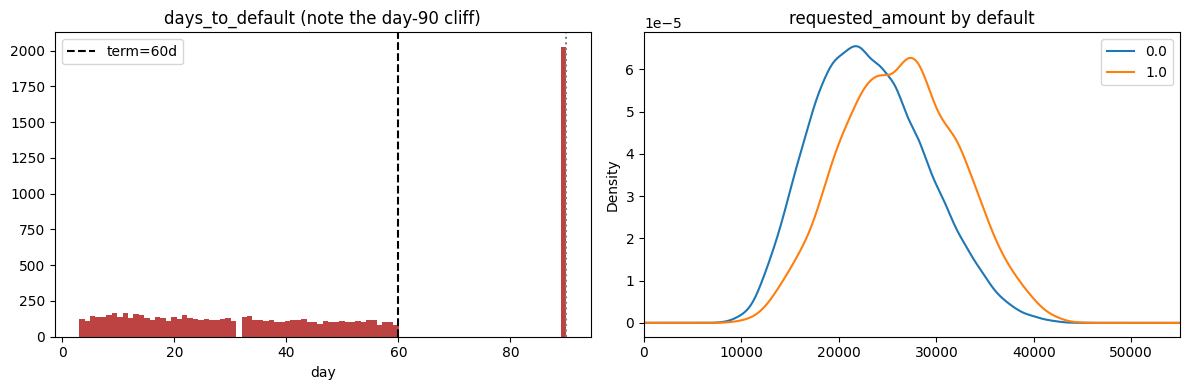

In [9]:
lab = data.labeled_mask(tr)
print("labeled (prior-approved & matured):", lab.sum(), f"({lab.mean():.1%})")
print("default rate among labeled:", round(tr.loc[lab,'default_flag'].mean(),4))
display(tr.loc[lab,'repayment_status'].value_counts())

fig, ax = plt.subplots(1,2, figsize=(12,4))
dtd = tr.loc[tr['default_flag']==1,'days_to_default']
ax[0].hist(dtd, bins=90, color='firebrick', alpha=.85)
ax[0].axvline(60, color='k', ls='--', label='term=60d'); ax[0].axvline(90, color='gray', ls=':')
ax[0].set_title("days_to_default (note the day-90 cliff)"); ax[0].set_xlabel("day"); ax[0].legend()
tr.loc[lab].groupby('default_flag')['requested_amount'].plot(kind='kde', ax=ax[1], legend=True)
ax[1].set_title("requested_amount by default"); ax[1].set_xlim(0,55000)
plt.tight_layout(); plt.show()

**Takeaway — the label.** Among labeled loans the default rate is **17.4%** (mildly imbalanced — no resampling needed). `days_to_default` runs 3–90 with a hard **spike at day 90** (the open-balance sweep) and almost nothing between the 60-day term and day 90. Defaults are **bimodal in time** — Deliverable B must reproduce that shape, not smooth it. Default and non-default loans barely differ in requested amount, so risk is not a loan-size story.

## 6. Missingness — table and heatmap

,null%_train,null%_val,null%_test
column,,,
days_to_default,0.894,0.883,1.000
final_recovered_amount,0.894,0.883,1.000
days_since_last_external_decline,0.502,0.497,0.490
days_to_full_repayment,0.500,0.549,1.000
days_since_last_inquiry_elsewhere,0.499,0.489,0.490
prior_approved_amount,0.394,0.432,0.437
default_flag,0.394,0.432,1.000
repayment_status,0.394,0.432,1.000
observation_status,0.394,0.432,1.000


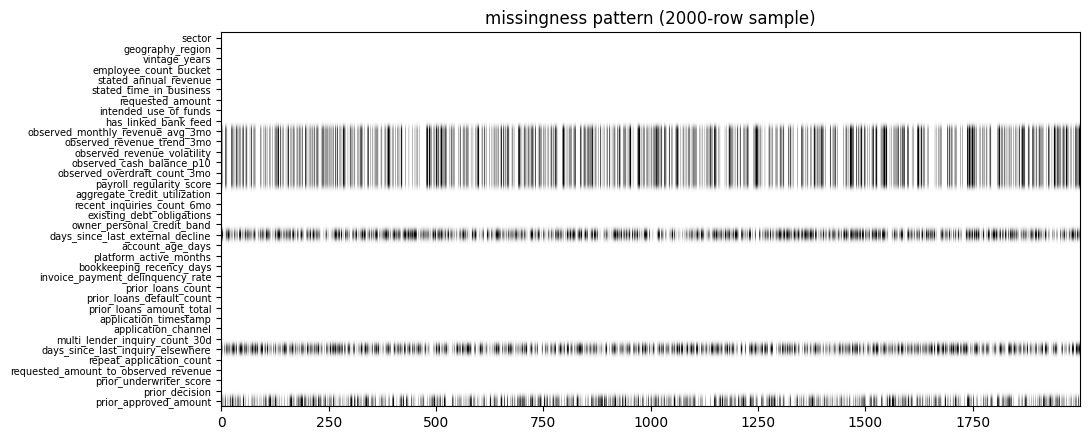

In [10]:
nullpct = ov[["column","null%_train","null%_val","null%_test"]].set_index("column")
nullpct = nullpct[nullpct.max(axis=1)>0].sort_values("null%_train", ascending=False)
display(nullpct)

fig, ax = plt.subplots(figsize=(11,4.5))
feat = data.feature_columns()
samp = tr[feat].sample(2000, random_state=0)
ax.imshow(samp.isna().T, aspect="auto", cmap="Greys")
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=7)
ax.set_title("missingness pattern (2000-row sample)"); plt.tight_layout(); plt.show()

## 7. Selection bias — who got approved? (the sharp 0.273 gate)
Labels only exist for prior-approved loans. The prior lender approved **iff
`prior_underwriter_score` ≥ ~0.273** — a hard cutoff with zero overlap.

observation_status  matured    NaN
prior_decision                    
0                         0  33618
1                     51722      0


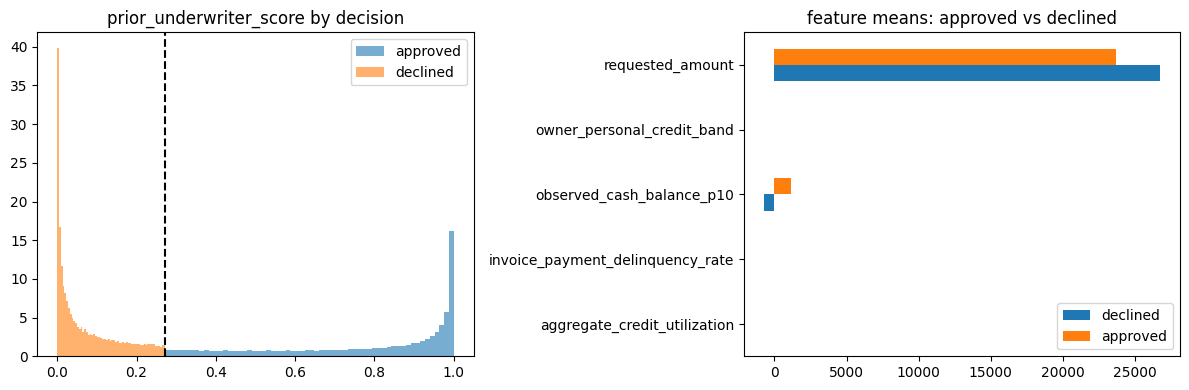

,declined,approved
aggregate_credit_utilization,0.597,0.439
invoice_payment_delinquency_rate,0.273,0.178
observed_cash_balance_p10,-757.147,"1,165.128"
owner_personal_credit_band,1.496,2.312
requested_amount,"26,768.364","23,724.462"


In [11]:
print(pd.crosstab(tr['prior_decision'], tr['observation_status'], dropna=False))
appr = tr['prior_decision']==1
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(tr.loc[appr,'prior_underwriter_score'].dropna(), bins=60, alpha=.6, density=True, label='approved')
ax[0].hist(tr.loc[~appr,'prior_underwriter_score'].dropna(), bins=60, alpha=.6, density=True, label='declined')
ax[0].axvline(0.273, color='k', ls='--'); ax[0].set_title("prior_underwriter_score by decision"); ax[0].legend()
# approved vs declined feature means, side by side
comp = tr.groupby(appr)[['aggregate_credit_utilization','invoice_payment_delinquency_rate',
        'observed_cash_balance_p10','owner_personal_credit_band','requested_amount']].mean().T
comp.columns=['declined','approved']; comp.plot(kind='barh', ax=ax[1])
ax[1].set_title("feature means: approved vs declined"); plt.tight_layout(); plt.show()
display(comp)

**Takeaway — selection bias (the central problem).** The prior lender approved **iff `prior_underwriter_score` ≥ 0.273** — a hard cutoff with essentially **zero score overlap** between approved and declined. Labels are therefore missing-not-at-random behind a deterministic gate: we can model on approved loans but **cannot validate PD on declines** (no common support → inverse-propensity reweighting is infeasible, not just inconvenient). Approved loans also look healthier on every axis (lower utilization/delinquency, higher cash), so the labeled sample is optimistic.

## 8. Timing structure for Deliverable B — cumulative default by loan-age week

day,1,2,3,4,5,6,7,8,9,10,11,12,13
cumulative_default_rate,0.013,0.033,0.050,0.068,0.085,0.100,0.114,0.128,0.135,0.135,0.135,0.135,0.174


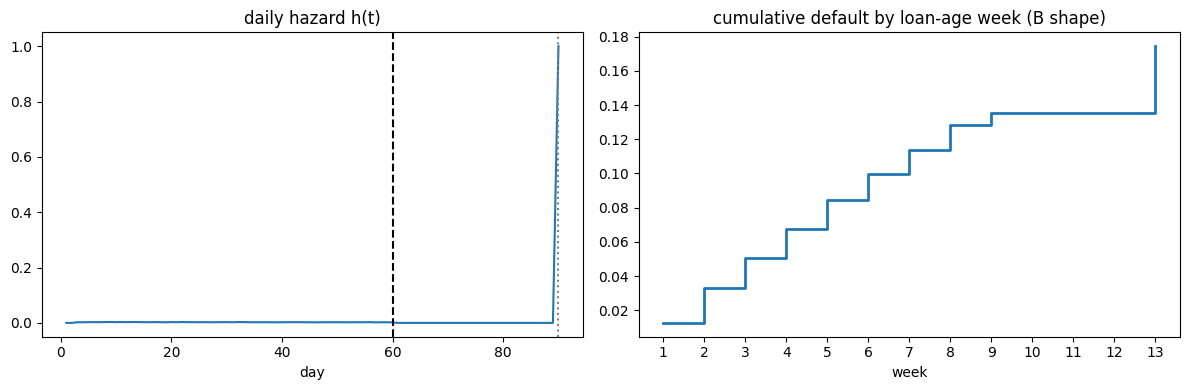

In [12]:
haz = data.assign_cohort_week  # noqa
from src import eda
H = eda.discrete_hazard(tr)
wk = (np.ceil(H['day']/7).astype(int)).clip(upper=13)
cdr = H.groupby(wk)['cum_default_frac'].max()
display(cdr.rename('cumulative_default_rate').to_frame().T)
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(H['day'], H['hazard']); ax[0].axvline(60, ls='--', c='k'); ax[0].axvline(90, ls=':', c='gray')
ax[0].set_title("daily hazard h(t)"); ax[0].set_xlabel("day")
ax[1].step(cdr.index, cdr.values, where='post', lw=2)
ax[1].set_title("cumulative default by loan-age week (B shape)"); ax[1].set_xlabel("week"); ax[1].set_xticks(range(1,14))
plt.tight_layout(); plt.show()

### Per-cohort default rate (validation) — the level target for B

cohort_week,1,2,3,4,5,6,7,8,9,10,11,12,13
mean,0.208,0.232,0.196,0.168,0.260,0.201,0.190,0.225,0.190,0.209,0.198,0.240,0.153
size,207.000,220.000,189.000,220.000,208.000,199.000,205.000,222.000,174.000,206.000,177.000,167.000,157.000


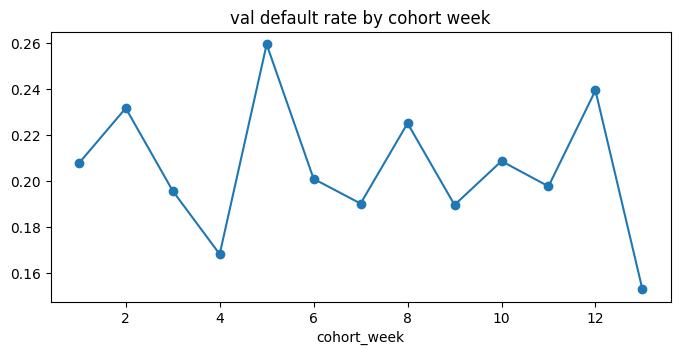

In [13]:
va2 = va.copy(); va2['cohort_week'] = data.assign_cohort_week(va2)
cr = va2[data.labeled_mask(va2)].groupby('cohort_week')['default_flag'].agg(['mean','size'])
display(cr.T)
cr['mean'].plot(marker='o', figsize=(8,3.5), title="val default rate by cohort week"); plt.show()

**Takeaway — Deliverable B shape × level.** Cumulative defaults rise concavely through ~week 9, flatten, then jump at week 13 (the day-90 sweep) — this *curve* is the B target. The per-cohort validation default rate gives the *level*. So we model B as **one normalized timing shape × a per-cohort level**, not 169 free numbers — robust given small per-cohort samples (n≈150).

## 9. Informative missingness — null IS signal

In [14]:
def rate_by(col, is_null_meaningful=True):
    d = tr[data.labeled_mask(tr)]
    if d[col].dtype==bool or set(d[col].dropna().unique())<= {True,False}:
        return d.groupby(col)['default_flag'].agg(['mean','size'])
    g = pd.Series(np.where(d[col].isna(),'null','present'), index=d.index)
    return d.groupby(g)['default_flag'].agg(['mean','size'])
for c in ['has_linked_bank_feed','days_since_last_external_decline','days_since_last_inquiry_elsewhere']:
    print(f"\n=== default rate by {c} ==="); print(rate_by(c).to_string())


=== default rate by has_linked_bank_feed ===
                      mean   size
has_linked_bank_feed             
False                0.191  16971
True                 0.167  34751

=== default rate by days_since_last_external_decline ===
         mean   size
null    0.143  28334
present 0.213  23388

=== default rate by days_since_last_inquiry_elsewhere ===
         mean   size
null    0.141  28164
present 0.214  23558


**Takeaway — null is signal.** Missingness predicts default, sometimes counter-intuitively: no-bank-feed loans default **19.1%** vs **16.7%** with a feed; but a *present* `external_decline` or `inquiry_elsewhere` field marks **~21%** default vs **~14%** when null — having been shopped around (or declined) elsewhere is the risk, so the *absence* of that history is reassuring. We encode these as first-class indicators rather than impute them away.

## 10. Self-reported vs observed revenue — misreporting signal

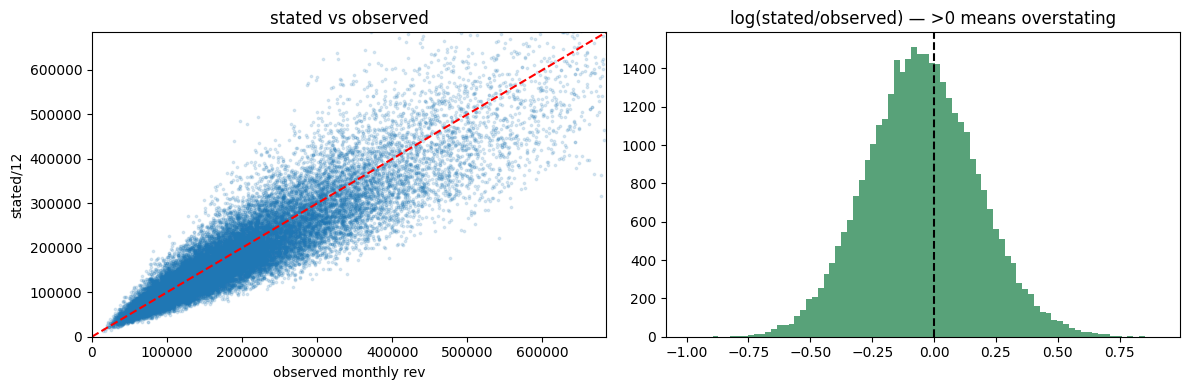

overstate >1.5x: 2.4% | default rate overstate vs not: 0.386 vs 0.161


In [15]:
m = data.labeled_mask(tr) & (tr['has_linked_bank_feed']==True)
d = tr.loc[m].copy()
d['stated_monthly'] = d['stated_annual_revenue']/12
d['ratio'] = d['stated_monthly']/d['observed_monthly_revenue_avg_3mo']
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(d['observed_monthly_revenue_avg_3mo'], d['stated_monthly'], s=3, alpha=.15)
lim=d['observed_monthly_revenue_avg_3mo'].quantile(.99)
ax[0].plot([0,lim],[0,lim],'r--'); ax[0].set_xlim(0,lim); ax[0].set_ylim(0,lim)
ax[0].set_xlabel("observed monthly rev"); ax[0].set_ylabel("stated/12"); ax[0].set_title("stated vs observed")
ax[1].hist(np.log(d['ratio'][d['ratio']>0]), bins=80, color='seagreen', alpha=.8); ax[1].axvline(0, c='k', ls='--')
ax[1].set_title("log(stated/observed) — >0 means overstating"); plt.tight_layout(); plt.show()
over = d['ratio']>1.5
print("overstate >1.5x:", f"{over.mean():.1%}", "| default rate overstate vs not:",
      round(d.loc[over,'default_flag'].mean(),3), "vs", round(d.loc[~over,'default_flag'].mean(),3))

**Takeaway — self-reports are optimistically biased.** Stated-vs-bank-feed revenue is well-calibrated in the bulk, but the **2.4% who overstate revenue >1.5×** default at **38.6%** vs **16.1%** for everyone else — a 2.4× lift. So the *gap* between stated and observed, not the stated figure itself, is the signal. This is exactly why Deliverable C treats `stated_*` interventions as **≈0 causal effect**: editing the number on the form does not change the business.

## 11. Entity structure & leakage canary

In [16]:
vc = tr['business_id'].value_counts()
print("businesses:", tr['business_id'].nunique(), "| with >1 app:", (vc>1).sum(), "| max apps:", vc.max())
print("overlap train/val/test:", len(set(tr.business_id)&set(va.business_id)),
      len(set(tr.business_id)&set(te.business_id)), len(set(va.business_id)&set(te.business_id)))
display(eda.leakage_audit(tr).head(12))

businesses: 68364 | with >1 app: 14425 | max apps: 4
overlap train/val/test: 0 0 0


,feature,auc,raw_auc
0,invoice_payment_delinquency_rate,0.751,0.751
1,aggregate_credit_utilization,0.735,0.735
2,observed_cash_balance_p10,0.679,0.321
3,requested_amount_to_observed_revenue,0.667,0.667
4,requested_amount,0.649,0.649
5,prior_approved_amount,0.640,0.640
6,owner_personal_credit_band,0.619,0.381
7,payroll_regularity_score,0.611,0.389
8,observed_revenue_volatility,0.608,0.608
9,existing_debt_obligations,0.607,0.607


**Takeaway — clean grouped split + honest drivers.** 68,364 businesses, 14,425 with repeat applications (up to 4), and **zero `business_id` overlap** across train/val/test — so GroupKFold by `business_id` is the correct CV and there's no entity leakage. The strongest univariate signals are invoice-payment delinquency (AUC **0.751**) and credit utilization (**0.735**) — recognized, regulator-defensible credit drivers, not proxies for protected attributes.

## 12. Class balance by segment

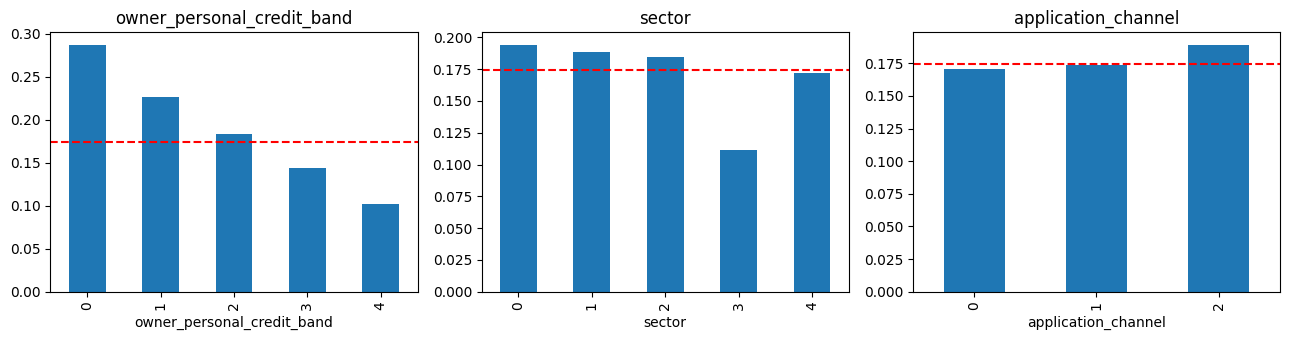

In [17]:
d = tr[data.labeled_mask(tr)]
fig, axes = plt.subplots(1,3, figsize=(13,3.5))
for ax,c in zip(axes, ['owner_personal_credit_band','sector','application_channel']):
    d.groupby(c)['default_flag'].mean().plot(kind='bar', ax=ax, title=c)
    ax.axhline(d['default_flag'].mean(), c='r', ls='--')
plt.tight_layout(); plt.show()

**Takeaway — segments + the bottom line.** Default risk varies with credit band, sector, and channel (bars vs the red overall-mean line), confirming the band-conditional treatment in B and the model. Four facts then drive the whole pipeline: **(1)** labels live only behind a 0.273 approval gate with no decline overlap; **(2)** default timing is bimodal with a day-90 cliff; **(3)** missingness and stated–observed gaps are informative; **(4)** loans are only ~1.4% of revenue, so default is cash-buffer-bound, not revenue-bound. The methodology in `reports/eda_findings.md` follows directly from these.

---
### Scratchpad — your turn
Everything above is live. Add cells below to slice however you like, e.g.:
```python
tr.query("has_linked_bank_feed == False")['default_flag'].mean()
tr.groupby('intended_use_of_funds')['default_flag'].mean()
```